<h1 style="text-align: center; color: purple;">Phase 1: AtliQo Bank Credit Card Project</h1>

<h2 style="text-align: center; color: purple;">Find Target Market</h2>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<h2 style="text-align: center; color: darkorange;">Data Import</h2>

### **Option 1: Read data from MySQL**

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import mysql.connector

conn = mysql.connector.connect(
    host='localhost',
    user='your_username',
    passwd='your_password',
    database='your_database'
)

In [4]:
df_cu = pd.read_sql("SELECT * FROM customers", conn)

In [5]:
df_cu.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211,Married
1,2,Anjali Pandey,Female,47,City,Consultant,65172,Single
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378,Married
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563,Married
4,5,Advait Malik,Male,48,City,Consultant,39406,Married


In [6]:
df_cu.shape

(1000, 8)

In [7]:
df_cp = pd.read_sql("SELECT * FROM credit_profiles", conn)

In [8]:
df_cp.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [9]:
df_cp.shape

(1004, 6)

In [10]:
df_ts = pd.read_sql("SELECT * FROM transactions", conn)

In [11]:
df_ts.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [12]:
df_ts.shape

(500000, 7)

### **Option 2. Read data from CSV files**

In [13]:
df_cu = pd.read_csv("data/customers.csv")

In [14]:
df_cu.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211.0,Married
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563.0,Married
4,5,Advait Malik,Male,48,City,Consultant,39406.0,Married


In [15]:
df_cu.shape

(1000, 8)

In [16]:
df_cp = pd.read_csv("data/credit_profiles.csv")

In [17]:
df_cp.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [18]:
df_cp.shape

(1004, 6)

In [19]:
df_ts = pd.read_csv("data/transactions.csv")

In [20]:
df_ts.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [21]:
df_ts.shape

(500000, 7)

<h2 style="text-align: center; color: darkorange;">Explore Customers Table</h2>

In [22]:
df_cu.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211.0,Married
1,2,Anjali Pandey,Female,47,City,Consultant,65172.0,Single
2,3,Aaryan Chauhan,Male,21,City,Freelancer,22378.0,Married
3,4,Rudra Bali,Male,24,Rural,Freelancer,33563.0,Married
4,5,Advait Malik,Male,48,City,Consultant,39406.0,Married


In [23]:
df_cu.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


### **Analyze annual income**

#### **1. Data Cleaning**

**1.1 Handling null values: Annual income**

In [24]:
df_cu.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

There are 50 null values in annual_income column.

In [25]:
df_cu[df_cu.annual_income.isna()].shape

(50, 8)

In [26]:
df_cu[df_cu.annual_income.isna()].head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Sanjana Malik,Female,25,Rural,Artist,NaN,Married
82,83,Reyansh Mukherjee,Male,27,City,Freelancer,NaN,Single
97,98,Virat Puri,Male,47,Suburb,Business Owner,NaN,Married
102,103,Aarav Shah,Male,32,City,Data Scientist,NaN,Married
155,156,Kiaan Saxena,Male,24,City,Fullstack Developer,NaN,Married


There are multiple ways to handle missing values:

**Remove them:**
Since there are 50 missing values in a dataset of 1000 rows, removing them is not ideal because it could result in the loss of potentially important information.

**Replace with mean or median:**
For income data, using the median is generally preferred. Income distributions often contain outliers, and the median is less affected by extreme values, making it a more robust choice than the mean.

**Replace with median by occupation:**
Income levels can differ significantly across occupations. Therefore, replacing missing values using the median income within each occupation group provides a more accurate and context-aware replacement.

In [27]:
occupation_wise_income_median = df_cu.groupby("occupation")["annual_income"].median()

In [28]:
occupation_wise_income_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [29]:
occupation_wise_income_median['Artist']

np.float64(45794.0)

In [30]:
def get_median_val(row):
    if pd.isnull(row["annual_income"]):
        return occupation_wise_income_median[row["occupation"]]
    else:
        return row["annual_income"]

In [31]:
get_median_val({"cust_id": 3245, "occupation": "Artist", "annual_income": 678})

678

In [32]:
# Replace null values in annual_income with the median income of their occupation group
df_cu['annual_income'] = df_cu.apply(
    lambda row: occupation_wise_income_median[row['occupation']] if pd.isnull(row['annual_income']) else row['annual_income'], axis=1)

In [33]:
df_cu.iloc[[14,82]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Sanjana Malik,Female,25,Rural,Artist,45794.0,Married
82,83,Reyansh Mukherjee,Male,27,City,Freelancer,46759.0,Single


Previously, the records at indices 14 and 82 had missing values for annual income. These values have now been replaced using the median income calculated for their respective occupations.


In [34]:
df_cu.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

The number of missing values across all columns is now zero. Since there are no null values, we can proceed to examine the distribution of annual income.

**1.2 Distribution of Annual income**

<Figure size 600x400 with 0 Axes>

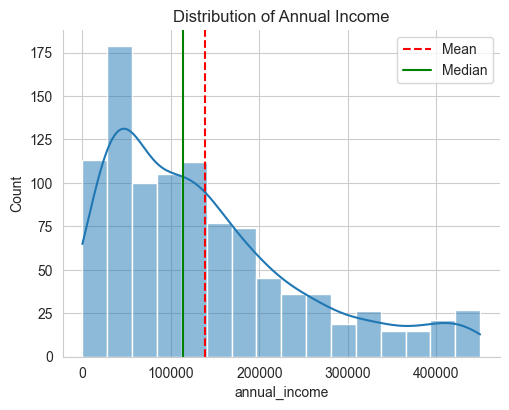

In [35]:
plt.figure(figsize=(6,4))
sns.displot(df_cu['annual_income'], kde=True, height=4, aspect=1.3)

plt.axvline(df_cu['annual_income'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df_cu['annual_income'].median(), color='green', linestyle='-', label='Median')

plt.legend()
plt.title('Distribution of Annual Income')

plt.savefig("data_visualization/distribution_of_annual_income.png", dpi=300, bbox_inches="tight")
plt.show()

The income distribution shown above is right-skewed. Let us now use the `describe()` function to obtain a quick summary of the key statistics.

In [36]:
df_cu.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,138916.765500
std,288.819436,15.666155,110969.408643
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,48229.500000
50%,500.500000,32.000000,113416.000000
75%,750.250000,46.000000,192614.000000
max,1000.000000,135.000000,449346.000000


We can make the following observations from the above summary:

**Age:** The minimum age is 1 and the maximum age is 135. These values appear unrealistic and indicate the presence of outliers in the age column.

**Annual Income:** The minimum income is 2 and the maximum is 449k. The minimum value seems incorrect, as the business has indicated that the minimum annual income should be at least 100$. This suggests the presence of outliers in the annual income column as well.


In [37]:
df_cu.annual_income.describe()

count      1000.000000
mean     138916.765500
std      110969.408643
min           2.000000
25%       48229.500000
50%      113416.000000
75%      192614.000000
max      449346.000000
Name: annual_income, dtype: float64

**1.3 Outlier Detection: Annual income**

Let us use the standard deviation method to detect outliers. A common approach is to treat any values lying beyond ±3 standard deviations from the mean as outliers.

In [38]:
df_cu['annual_income'].mean(), df_cu['annual_income'].std()

(np.float64(138916.7655), np.float64(110969.4086433663))

In [39]:
lower = df_cu['annual_income'].mean() - 3*df_cu['annual_income'].std()
upper = df_cu['annual_income'].mean() + 3*df_cu['annual_income'].std()

lower, upper

(np.float64(-193991.4604300989), np.float64(471824.9914300989))

In [40]:
df_cu[df_cu['annual_income']>upper]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


Based on the ±3 standard deviation rule, no upper-end outliers are observed.

However, the minimum income is 2, which falls below the business-defined threshold of 100. Therefore, values under 100 can be treated as lower-end outliers. These outliers could have occurred due to a data error.


In [41]:
df_cu[df_cu.annual_income<100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Mistry,Male,50,City,Business Owner,50.0,Married
262,263,Vivaan Tandon,Male,53,Suburb,Business Owner,50.0,Married
316,317,Yuvraj Saxena,Male,47,City,Consultant,50.0,Married
333,334,Avani Khanna,Female,29,City,Data Scientist,50.0,Married
340,341,Priya Sinha,Female,33,Rural,Fullstack Developer,50.0,Married
543,544,Advait Batra,Male,54,City,Consultant,2.0,Married
592,593,Priya Gandhi,Female,32,City,Business Owner,50.0,Married
633,634,Rudra Mehtani,Male,26,City,Data Scientist,2.0,Married
686,687,Vihaan Jaiswal,Male,40,City,Business Owner,2.0,Married
696,697,Ishan Negi,Male,47,City,Consultant,20.0,Married


**Outlier Treatment: Annual Income**

Records with income below 100$ are considered outliers. The following approaches can be used to handle them:

* **Remove them:** After discussion with the business team, we decided not to drop these records because they represent valid customers that should remain in the analysis.
* **Replace with mean or median:** Since the mean is sensitive to extreme values, the median is a more robust choice for replacing income.
* **Replace with occupation-wise median:** Income typically varies by occupation. For instance, the median income of a data scientist may differ from that of a business owner. Therefore, replacing outliers with the median income calculated within each occupation group is a more appropriate approach.


In [42]:
occupation_wise_income_median["Artist"]

np.float64(45794.0)

In [43]:
for index, row in df_cu.iterrows():
    if row["annual_income"] < 100:
        occupation = df_cu.at[index, "occupation"]
        df_cu.at[index, "annual_income"] = occupation_wise_income_median[occupation]

In [44]:
df_cu[df_cu.annual_income<100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [45]:
df_cu.loc[[31,316]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Mistry,Male,50,City,Business Owner,261191.5,Married
316,317,Yuvraj Saxena,Male,47,City,Consultant,58017.0,Married


Records at indices 31 and 316 had annual incomes below $100. These values have now been replaced with the median income corresponding to their respective occupations.

#### **2. Data Visualization**

**2.1 Average income across different groups**

We will analyze the average income across different groups, including occupation, gender, location, and marital status.

In [46]:
avg_income_per_occupation  = df_cu.groupby("occupation")["annual_income"].mean()

In [47]:
avg_income_per_occupation

occupation
Accountant              64123.562500
Artist                  45309.236842
Business Owner         268447.368512
Consultant              60703.154639
Data Scientist         137021.266304
Freelancer              76327.508772
Fullstack Developer     78727.972973
Name: annual_income, dtype: float64

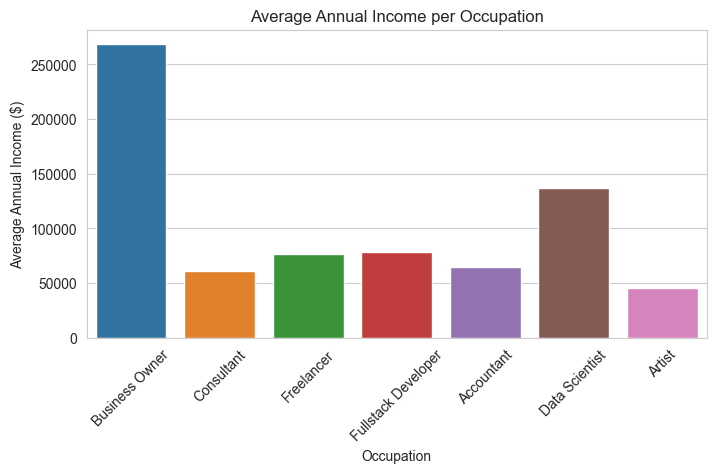

In [48]:
plt.figure(figsize=(8,4))

sns.barplot(data=df_cu,x="occupation",y="annual_income",estimator="mean",palette="tab10", errorbar=None)

plt.xticks(rotation=45)
plt.title("Average Annual Income per Occupation")
plt.xlabel("Occupation")
plt.ylabel("Average Annual Income ($)")

plt.savefig("data_visualization/average_annual_income_per_occupation.png", dpi=300, bbox_inches="tight")
plt.show()

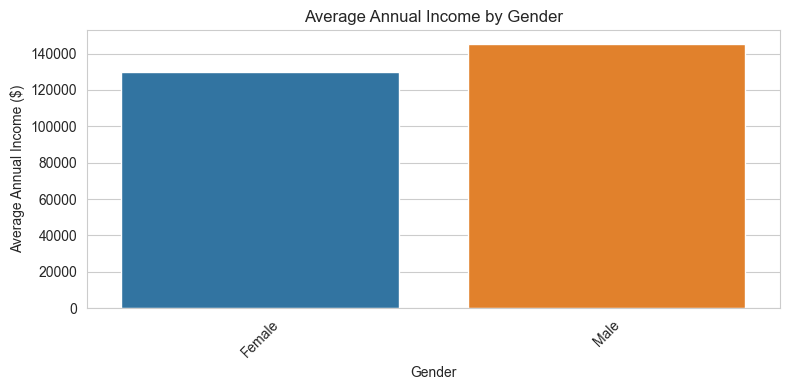

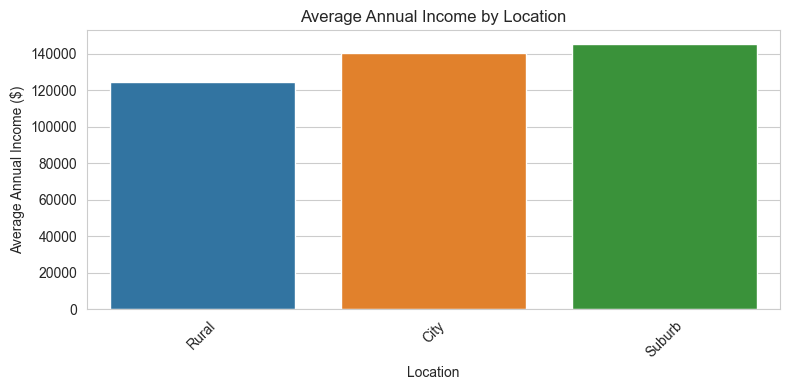

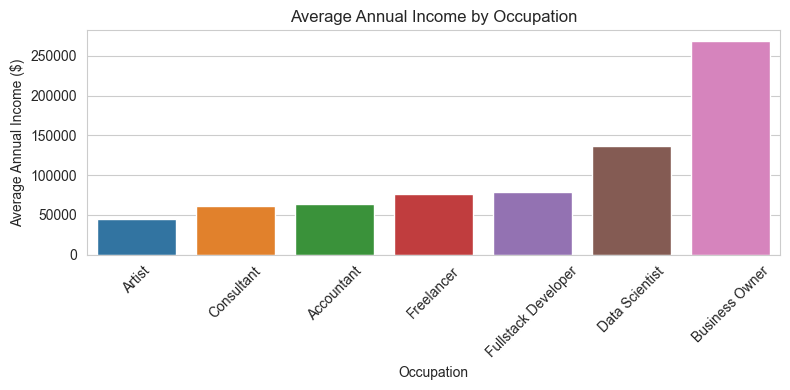

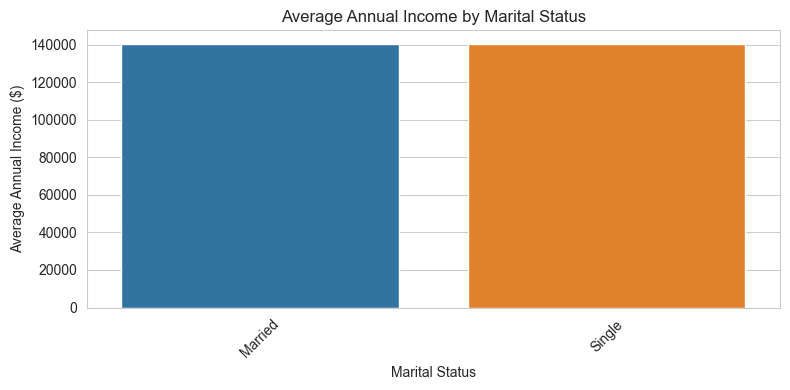

In [49]:
# List of categorical columns
categorical_columns = ['gender', 'location', 'occupation', 'marital_status']

# Loop through each categorical column and plot a bar chart of average annual income
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df_cu,x=col,y="annual_income",estimator="mean",errorbar=None,
        order=df_cu.groupby(col)["annual_income"].mean().sort_values().index,palette="tab10")

    plt.xticks(rotation=45)
    plt.title(f"Average Annual Income by {col.replace('_',' ').title()}")
    plt.xlabel(col.replace('_',' ').title())
    plt.ylabel("Average Annual Income ($)")
    plt.tight_layout()
    plt.show()

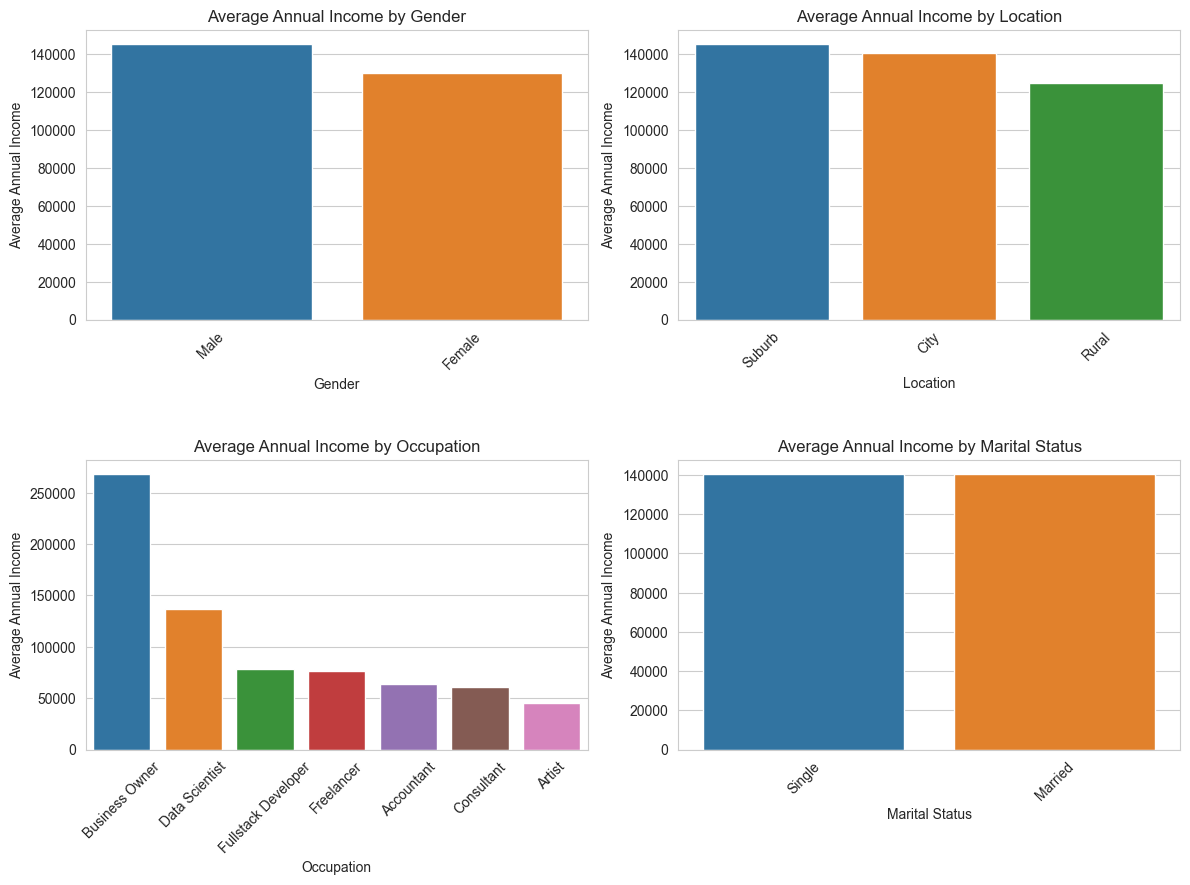

In [50]:
# List of categorical columns
cat_cols = ['gender', 'location', 'occupation', 'marital_status']

num_rows = 3
# Create subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(12, 4 * num_rows))

# Flatten the axes array to make it easier to iterate
axes = axes.flatten()

# Create subplots for each categorical column
for i, col in enumerate(cat_cols):

    # Sort categories by average income
    order = (df_cu.groupby(col)["annual_income"].mean().sort_values(ascending=False).index)

    sns.barplot(data=df_cu,x=col,y="annual_income",estimator="mean",errorbar=None,order=order,palette="tab10",ax=axes[i])

    axes[i].set_title(f"Average Annual Income by {col.replace('_',' ').title()}")
    axes[i].set_xlabel(col.replace('_',' ').title())
    axes[i].set_ylabel("Average Annual Income")
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig("data_visualization/average_annual_income_by_demographics.png", dpi=300, bbox_inches="tight")
plt.show()

#### **Analyze age column**

#### **1. Data Cleaning**

**1.1 Handling null values: Age column**

First, we check whether there are any null values in the Age column.

In [51]:
df_cu.age.isnull().sum()

np.int64(0)

No null values were found in the Age column, so no further handling is required.

In [52]:
df_cu.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,140483.548500
std,288.819436,15.666155,110463.002934
min,1.000000,1.000000,5175.000000
25%,250.750000,26.000000,49620.500000
50%,500.500000,32.000000,115328.000000
75%,750.250000,46.000000,195514.250000
max,1000.000000,135.000000,449346.000000


**1.2 Outlier Treatment: Age**

The minimum age is 1 and the maximum age is 135, which appear to be outliers. Therefore, let's examine the age distribution.

In [53]:
min_age = df_cu.age.min()
max_age = df_cu.age.max()

min_age, max_age

(np.int64(1), np.int64(135))

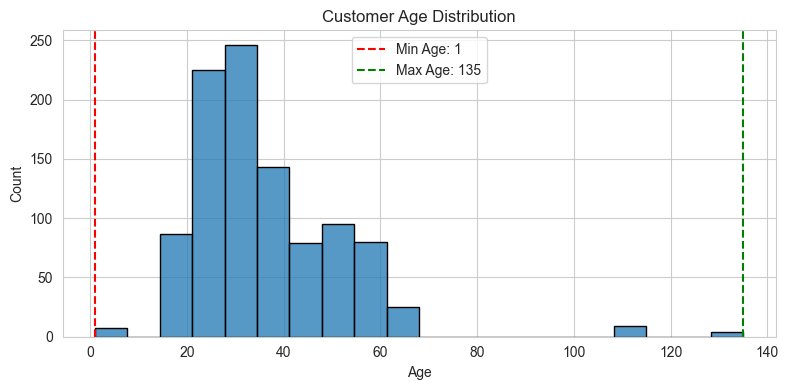

In [54]:
plt.figure(figsize=(8,4))

sns.histplot(data=df_cu, x="age", bins=20, edgecolor="black")

plt.axvline(df_cu["age"].min(), color="red", linestyle="--",
            label=f"Min Age: {df_cu['age'].min()}")

plt.axvline(df_cu["age"].max(), color="green", linestyle="--",
            label=f"Max Age: {df_cu['age'].max()}")

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Customer Age Distribution")
plt.legend()

plt.tight_layout()

plt.savefig("data_visualization/customer_age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

From the above, we will identify all customers aged above 80 and below 15.

In [55]:
df_cu[(df_cu.age<15)|(df_cu.age>80)]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211.0,Married
41,42,Aaryan Shah,Male,110,City,Artist,7621.0,Married
165,166,Sia Dutta,Female,1,City,Freelancer,39721.0,Single
174,175,Rohan Sharma,Male,110,City,Freelancer,23723.0,Married
222,223,Arjun Batra,Male,110,Suburb,Freelancer,210987.0,Married
277,278,Aarav Tandon,Male,110,City,Consultant,96522.0,Single
295,296,Ayush Pandey,Male,1,Rural,Accountant,55254.0,Married
325,326,Virat Goel,Male,110,City,Accountant,61021.0,Single
610,611,Rehan Verma,Male,135,Rural,Business Owner,444776.0,Married
692,693,Dhruv Jha,Male,1,City,Business Owner,83045.0,Married


In [56]:
outliers_age = df_cu[(df_cu.age<15)|(df_cu.age>80)]
outliers_age.shape

(20, 8)

There are 20 age outliers in total. How should we handle them?

Possible options:

* **Remove them:** This may not be ideal, as it would lead to the loss of potentially important information.
* **Replace outlier values with an appropriate value:** We can replace these values using the mean or median age.


In [57]:
df_cu.age.median()

np.float64(32.0)

Instead of replacing the outliers with the overall median age for all customers, we can compute the median age for each occupation and use the corresponding occupation-wise median for replacement.


In [58]:
outliers_age.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,2,City,Business Owner,358211.0,Married
41,42,Aaryan Shah,Male,110,City,Artist,7621.0,Married
165,166,Sia Dutta,Female,1,City,Freelancer,39721.0,Single
174,175,Rohan Sharma,Male,110,City,Freelancer,23723.0,Married
222,223,Arjun Batra,Male,110,Suburb,Freelancer,210987.0,Married


In [59]:
# calculate the median age for each occupation and use those values to replace the outliers.
median_age_per_occupation = df_cu.groupby('occupation')['age'].median()

In [60]:
median_age_per_occupation

occupation
Accountant             31.5
Artist                 26.0
Business Owner         51.0
Consultant             46.0
Data Scientist         32.0
Freelancer             24.0
Fullstack Developer    27.5
Name: age, dtype: float64

In [61]:
df_cu['age'] = df_cu['age'].astype(float)

In [62]:
for index, row in outliers_age.iterrows():
    if pd.notnull(row['age']):
        occupation = df_cu.at[index, 'occupation']
        df_cu.at[index, 'age'] = median_age_per_occupation[occupation]

In [63]:
df_cu[(df_cu.age<15)|(df_cu.age>80)]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [64]:
df_cu.age.describe()

count    1000.000000
mean       35.541500
std        12.276634
min        18.000000
25%        26.000000
50%        32.000000
75%        44.250000
max        64.000000
Name: age, dtype: float64

As shown above, there are no remaining outliers. The minimum age is now 18 and the maximum age is 64.


In [65]:
df_cu.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married
1,2,Anjali Pandey,Female,47.0,City,Consultant,65172.0,Single
2,3,Aaryan Chauhan,Male,21.0,City,Freelancer,22378.0,Married
3,4,Rudra Bali,Male,24.0,Rural,Freelancer,33563.0,Married
4,5,Advait Malik,Male,48.0,City,Consultant,39406.0,Married


#### **2. Data Visualization**

**2.1 Distribution of age groups**

In [66]:
# Define the bin edges and labels
bin_edges = [17, 25, 48, 65]  # Adjust as needed
bin_labels = ['18-25', '26-48', '49-65']

# Use the cut function to bin and label the age column
pd.cut(df_cu['age'], bins=bin_edges, labels=bin_labels)

0      49-65
1      26-48
2      18-25
3      18-25
4      26-48
       ...  
995    26-48
996    49-65
997    26-48
998    26-48
999    26-48
Name: age, Length: 1000, dtype: category
Categories (3, str): ['18-25' < '26-48' < '49-65']

In [67]:
# Define the bin edges and labels
bin_edges = [17, 25, 48, 65]  # Adjust as needed
bin_labels = ['18-25', '26-48', '49-65']

# Use the cut function to bin and label the age column
df_cu['age_group'] = pd.cut(df_cu['age'], bins=bin_edges, labels=bin_labels)

In [68]:
df_cu.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65
1,2,Anjali Pandey,Female,47.0,City,Consultant,65172.0,Single,26-48
2,3,Aaryan Chauhan,Male,21.0,City,Freelancer,22378.0,Married,18-25
3,4,Rudra Bali,Male,24.0,Rural,Freelancer,33563.0,Married,18-25
4,5,Advait Malik,Male,48.0,City,Consultant,39406.0,Married,26-48


In [69]:
df_cu['age_group'].value_counts(normalize=True)*100

age_group
26-48    56.7
18-25    24.6
49-65    18.7
Name: proportion, dtype: float64

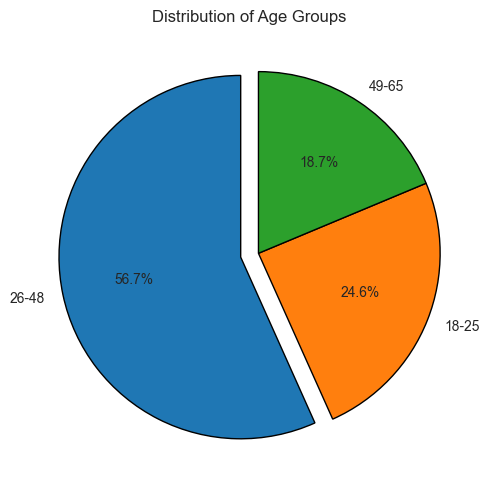

In [70]:
# Calculate the count of values in each age group
age_group_counts = (df_cu["age_group"].value_counts(normalize=True)* 100)

# Plot the pie chart
plt.figure(figsize=(5, 5))
plt.pie(age_group_counts,labels=age_group_counts.index,autopct="%1.1f%%",startangle=90,explode = [0.1] + [0]*(len(age_group_counts)-1),
        wedgeprops={"edgecolor": "black"},textprops={"fontsize": 10})

plt.title("Distribution of Age Groups")
plt.axis("equal")

plt.tight_layout()

plt.savefig("data_visualization/distribution_of_age_groups.png", dpi=300, bbox_inches="tight")
plt.show()

More than 56% of the customer base falls within the 26–48 age group, while approximately 25% belong to the 18–25 age group.

**2.2. Analyze gender and location distribution**

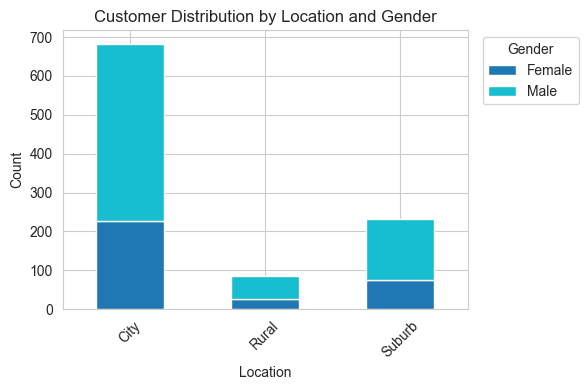

In [71]:
# Create customer count table by location and gender
customer_location_gender = (df_cu.groupby(['location', 'gender']).size().unstack(fill_value=0))

# Plot stacked bar chart for customer distribution
ax = customer_location_gender.plot(kind='bar',stacked=True,figsize=(6,4),colormap='tab10')

# Set axis labels and title
ax.set_xlabel('Location')
ax.set_ylabel('Count')
ax.set_title('Customer Distribution by Location and Gender')

# Add legend
plt.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')

# Rotate x-axis labels
plt.xticks(rotation=45)

# Adjust layout and display plot
plt.tight_layout()

plt.savefig("data_visualization/customer_distribution_by_location_and_gender.png", dpi=300, bbox_inches="tight")
plt.show()

<h2 style="text-align: center; color: darkorange;">Explore Credit Score Table</h2>

In [72]:
df_cp.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


#### **1. Data Cleaning**

**1.1 Remove duplicates**

In [73]:
df_cp.shape

(1004, 6)

There are 1,004 rows in this dataframe, whereas the customers dataframe contains only 1,000. This suggests that there may be duplicate or invalid records present in this dataframe.

In [74]:
df_cp['cust_id'].nunique()

1000

In [75]:
df_cp.duplicated('cust_id')

0       False
1       False
2       False
3       False
4       False
        ...  
999     False
1000    False
1001    False
1002    False
1003    False
Length: 1004, dtype: bool

In [76]:
df_cp[df_cp.duplicated('cust_id', keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
516,517,308,NaN,NaN,NaN,NaN
517,517,308,0.113860,33.0,3.0,500.0
569,569,344,NaN,NaN,NaN,NaN
570,569,344,0.112599,37.0,0.0,500.0
607,606,734,NaN,NaN,NaN,NaN
608,606,734,0.193418,4392.0,1.0,40000.0
664,662,442,NaN,NaN,NaN,NaN
665,662,442,0.856039,266.0,2.0,500.0


In [77]:
df_cp_clean_1 = df_cp.drop_duplicates(subset='cust_id', keep="last")

In [78]:
df_cp_clean_1.shape

(1000, 6)

In [79]:
df_cp_clean_1[df_cp_clean_1.duplicated('cust_id', keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit


This cleaned dataframe now appears consistent after removing duplicates. The next step is to check whether there are any null values.

**1.2 Handling null values**

In [80]:
df_cp_clean_1.isnull().sum()

cust_id                            0
credit_score                       0
credit_utilisation                 0
outstanding_debt                   0
credit_inquiries_last_6_months     0
credit_limit                      65
dtype: int64

Looking at **credit_limit**, we observe several null values that need to be handled. Based on business knowledge, credit limit depends on a customer's credit score. Therefore, we will try to determine whether a mathematical relationship exists between credit score and credit limit, and then use credit score to fill the null values in credit limit. Let's explore this further.

In [81]:
df_cp_clean_1[df_cp_clean_1.credit_limit.isnull()]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
10,11,679,0.557450,9187.0,2.0,NaN
35,36,790,0.112535,4261.0,1.0,NaN
37,38,514,0.296971,238.0,2.0,NaN
45,46,761,0.596041,24234.0,2.0,NaN
64,65,734,0.473715,13631.0,0.0,NaN
...,...,...,...,...,...,...
912,909,479,0.487555,320.0,3.0,NaN
931,928,311,0.832244,316.0,2.0,NaN
948,945,526,0.272734,227.0,1.0,NaN
954,951,513,0.175914,131.0,3.0,NaN


In [82]:
df_cp_clean_1['credit_limit'].unique()

array([40000.,  1250.,  1000.,   500.,   750.,    nan,  1500., 60000.,
       20000.])

The credit limit has only a few unique values. Let's check the count for each of these values.

In [83]:
df_cp_clean_1['credit_limit'].value_counts()

credit_limit
500.0      229
60000.0    186
40000.0    137
1500.0     100
1000.0      90
750.0       76
1250.0      75
20000.0     42
Name: count, dtype: int64

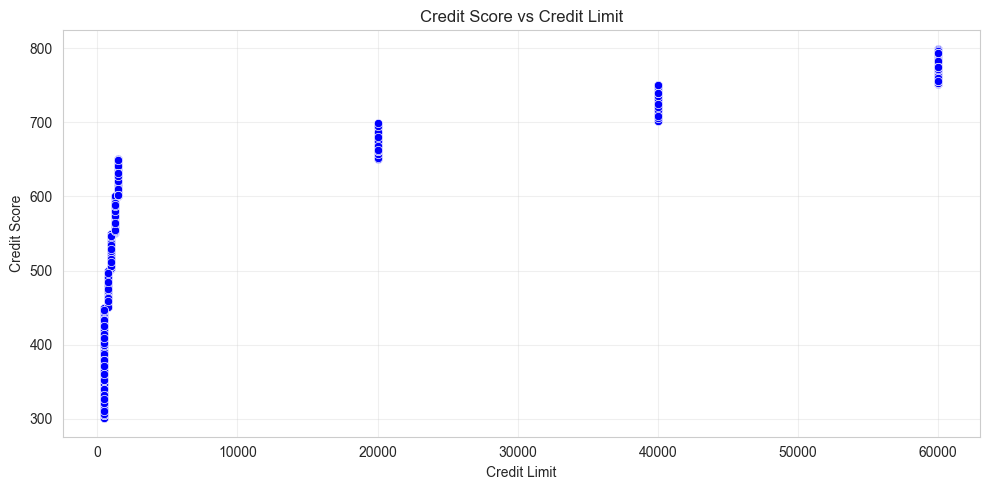

In [84]:
# Create a scatter plot
plt.figure(figsize=(10,5))
sns.scatterplot(data=df_cp_clean_1,x="credit_limit",y="credit_score",color="blue")

# Customize the plot
plt.title("Credit Score vs Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Credit Score")

# Add grid for better readability
plt.grid(alpha=0.3)

# Adjust layout and display plot
plt.tight_layout()

plt.savefig("data_visualization/credit_score_vs_credit_limit.png", dpi=300, bbox_inches="tight")
plt.show()

Here, we can observe a clear relationship between credit score and credit limit. There are distinct levels: customers with a score up to 650 receive a very small credit limit (less than $1,000), those with scores between 650 and 700 receive around 20K, and scores between 700 and 750 receive approximately 40K, and so on.


In [85]:
# Define bin ranges
bin_ranges = [300, 450, 500, 550, 600, 650, 700, 750, 800]

# Create labels for the bins
bin_labels = [f'{start}-{end-1}' for start, end in zip(bin_ranges, bin_ranges[1:])]

# Use pd.cut to assign data to bins
df_cp_clean_1['credit_score_range'] = pd.cut(df_cp_clean_1['credit_score'], bins=bin_ranges, labels=bin_labels, include_lowest=True, right=False)

In [86]:
df_cp_clean_1.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700-749
1,2,587,0.107928,161644.0,2.0,1250.0,550-599
2,3,544,0.854807,513.0,4.0,1000.0,500-549
3,4,504,0.336938,224.0,2.0,1000.0,500-549
4,5,708,0.586151,18090.0,2.0,40000.0,700-749


We can now see a new column called **credit_score_range**, which is derived from the **credit_score** column.


In [87]:
df_cp_clean_1[['credit_score','credit_score_range', 'credit_limit']].head()

,credit_score,credit_score_range,credit_limit
0,749,700-749,40000.0
1,587,550-599,1250.0
2,544,500-549,1000.0
3,504,500-549,1000.0
4,708,700-749,40000.0


In [88]:
df_cp_clean_1[df_cp_clean_1['credit_score_range']=="750-799"]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
21,22,785,0.897089,36083.0,3.0,60000.0,750-799
25,26,758,0.250811,190838.0,2.0,60000.0,750-799
26,27,766,0.830908,31344.0,3.0,60000.0,750-799
29,30,798,0.222597,7238.0,2.0,60000.0,750-799
31,32,768,0.747793,35109.0,2.0,60000.0,750-799
...,...,...,...,...,...,...,...
988,985,770,0.628088,33405.0,2.0,60000.0,750-799
993,990,772,0.259958,11937.0,2.0,60000.0,750-799
996,993,782,0.477170,20305.0,2.0,60000.0,750-799
1000,997,774,0.465462,17139.0,0.0,60000.0,750-799


In [89]:
df_cp_clean_1[df_cp_clean_1['credit_score_range']=="300-449"]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
5,6,442,0.705409,246.0,4.0,500.0,300-449
11,12,429,0.627645,263.0,0.0,500.0,300-449
15,16,347,0.531660,190.0,0.0,500.0,300-449
18,19,447,0.795650,292.0,1.0,500.0,300-449
20,21,381,0.714710,307.0,0.0,500.0,300-449
...,...,...,...,...,...,...,...
981,978,371,0.435307,183.0,2.0,500.0,300-449
982,979,332,0.150815,65.0,1.0,500.0,300-449
984,981,327,0.377202,108.0,3.0,500.0,300-449
989,986,425,0.178470,56.0,4.0,500.0,300-449


As shown above, the credit limit for the **750–799** credit score range is 60K, whereas for the **300–449** range it is 500. We can use the mode function to identify the most frequently occurring credit limit for each score range.


In [90]:
mode_df = df_cp_clean_1.groupby('credit_score_range')['credit_limit'].agg(lambda x: x.mode().iloc[0]).reset_index()

In [91]:
mode_df

,credit_score_range,credit_limit
0,300-449,500.0
1,450-499,750.0
2,500-549,1000.0
3,550-599,1250.0
4,600-649,1500.0
5,650-699,20000.0
6,700-749,40000.0
7,750-799,60000.0


In [92]:
df_cp_clean_1[df_cp_clean_1.credit_limit.isnull()].sample(5)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
399,400,754,0.884299,32031.0,2.0,NaN,750-799
107,108,500,0.776230,448.0,2.0,NaN,500-549
489,490,766,0.194645,9079.0,1.0,NaN,750-799
690,687,736,0.738382,17882.0,3.0,NaN,700-749
325,326,599,0.791918,501.0,0.0,NaN,550-599


In [93]:
# Merge the mode values back with the original DataFrame
df_cp_clean_2 = pd.merge(df_cp_clean_1, mode_df, on='credit_score_range', suffixes=('', '_mode'))

In [94]:
df_cp_clean_2.sample(5)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
230,231,744,0.251682,5463.0,0.0,40000.0,700-749,40000.0
645,646,310,0.694213,233.0,1.0,500.0,300-449,500.0
687,688,490,0.290973,116.0,1.0,750.0,450-499,750.0
126,127,522,0.287678,204.0,4.0,NaN,500-549,1000.0
538,539,775,0.519054,26482.0,4.0,60000.0,750-799,60000.0


In [95]:
df_cp_clean_2[df_cp_clean_2.credit_limit.isnull()].sample(5)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
852,853,497,0.873269,416.0,3.0,NaN,450-499,750.0
114,115,619,0.128910,151.0,1.0,NaN,600-649,1500.0
10,11,679,0.557450,9187.0,2.0,NaN,650-699,20000.0
399,400,754,0.884299,32031.0,2.0,NaN,750-799,60000.0
167,168,737,0.489797,12421.0,2.0,NaN,700-749,40000.0


We can now replace the NaN values in the **credit_limit** column with the **credit_limit_mode**. This value represents the most frequently occurring credit limit for a given **credit_score_range**, making it suitable for imputation.

We will create a new copy of the dataframe to maintain reproducibility and preserve access to the original dataframe in this notebook.


In [96]:
df_cp_clean_3 = df_cp_clean_2.copy()

In [97]:
df_cp_clean_3['credit_limit'] = df_cp_clean_3['credit_limit'].fillna(df_cp_clean_3['credit_limit_mode'])

In [98]:
df_cp_clean_3.shape

(1000, 8)

In [99]:
df_cp_clean_3.head(20)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0,550-599,1250.0
2,3,544,0.854807,513.0,4.0,1000.0,500-549,1000.0
3,4,504,0.336938,224.0,2.0,1000.0,500-549,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0,700-749,40000.0
5,6,442,0.705409,246.0,4.0,500.0,300-449,500.0
6,7,747,0.523965,15544.0,4.0,40000.0,700-749,40000.0
7,8,482,0.121775,76.0,2.0,750.0,450-499,750.0
8,9,537,0.448924,341.0,0.0,1000.0,500-549,1000.0
9,10,567,0.533402,522.0,0.0,1250.0,550-599,1250.0


In [100]:
df_cp_clean_3.isnull().sum()

cust_id                           0
credit_score                      0
credit_utilisation                0
outstanding_debt                  0
credit_inquiries_last_6_months    0
credit_limit                      0
credit_score_range                0
credit_limit_mode                 0
dtype: int64

You can now see zero NaN values in the **credit_limit** column, which indicates that all null values have been successfully handled.


In [101]:
df_cp_clean_3[df_cp_clean_3.cust_id==648]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
647,648,405,0.231599,63.0,0.0,500.0,300-449,500.0


Previously, customer ID 648 had a null value in the **credit_limit** column. It now has a valid value.


**1.3 Handling outliers: outstanding_debt**

In [102]:
df_cp_clean_3.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_limit_mode
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,589.182000,0.498950,9683.597000,1.955000,19733.75000,19912.500000
std,288.819436,152.284929,0.233139,25255.893671,1.414559,24717.43818,24840.914633
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.00000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.00000,750.000000
50%,500.500000,601.500000,0.487422,550.000000,2.000000,1500.00000,1500.000000
75%,750.250000,738.000000,0.697829,11819.500000,3.000000,40000.00000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.00000,60000.000000


When we compare the minimum and maximum values across columns, we notice that the maximum value of **outstanding_debt** exceeds the maximum **credit_limit**. Based on business logic, a customer's debt should not exceed their credit limit, as they cannot spend beyond that limit. Let's check how many such cases exist in the dataset.


#### **2. Data Visualization**

**2.1 Visualizing outliers**

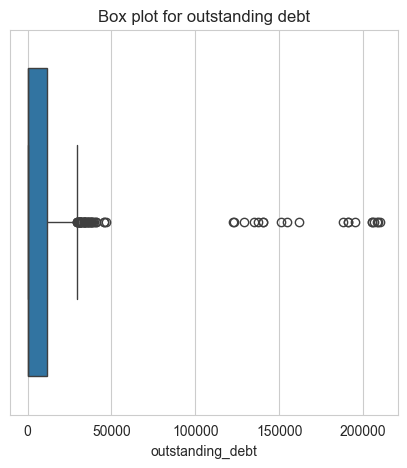

In [103]:
plt.figure(figsize=(5, 5))
sns.boxplot(x=df_cp_clean_3['outstanding_debt'])
plt.title('Box plot for outstanding debt')
plt.savefig("data_visualization/box_plot_for_outstanding_debt.png", dpi=300, bbox_inches="tight")

Instead of using a statistical approach such as standard deviation or IQR, we will rely on business logic. Any outstanding debt that exceeds the credit limit will be considered an outlier.

In [104]:
df_cp_clean_3[df_cp_clean_3.outstanding_debt>df_cp_clean_3.credit_limit]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
1,2,587,0.107928,161644.0,2.0,1250.0,550-599,1250.0
19,20,647,0.439132,205014.0,3.0,1500.0,600-649,1500.0
25,26,758,0.250811,190838.0,2.0,60000.0,750-799,60000.0
38,39,734,0.573023,122758.0,3.0,40000.0,700-749,40000.0
93,94,737,0.739948,137058.0,2.0,40000.0,700-749,40000.0
204,205,303,0.364360,187849.0,0.0,500.0,300-449,500.0
271,272,703,0.446886,154568.0,1.0,40000.0,700-749,40000.0
301,302,722,0.608076,122402.0,4.0,40000.0,700-749,40000.0
330,331,799,0.363420,208898.0,4.0,60000.0,750-799,60000.0
350,351,320,0.285081,150860.0,0.0,500.0,300-449,500.0


We replace these outliers with the credit limit. We assume the unusually high values are due to a data processing error, so replacing them with the credit limit is reasonable.

In [105]:
df_cp_clean_3.loc[df_cp_clean_3['outstanding_debt'] > df_cp_clean_3['credit_limit'], 'outstanding_debt']

1      161644.0
19     205014.0
25     190838.0
38     122758.0
93     137058.0
204    187849.0
271    154568.0
301    122402.0
330    208898.0
350    150860.0
446    206191.0
544    135112.0
636    140063.0
646    128818.0
698    190717.0
723    140008.0
725    205404.0
730    209901.0
766    195004.0
862    208406.0
Name: outstanding_debt, dtype: float64

In [106]:
df_cp_clean_3.loc[df_cp_clean_3['outstanding_debt'] > df_cp_clean_3['credit_limit'], 'outstanding_debt'] = df_cp_clean_3['credit_limit']

In [107]:
df_cp_clean_3.loc[[38, 204]]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
38,39,734,0.573023,40000.0,3.0,40000.0,700-749,40000.0
204,205,303,0.364360,500.0,0.0,500.0,300-449,500.0


All outliers in the `outstanding_debt` column are now gone.

In [108]:
df_cp_clean_3.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_limit_mode
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,589.182000,0.498950,6850.084000,1.955000,19733.75000,19912.500000
std,288.819436,152.284929,0.233139,10683.473561,1.414559,24717.43818,24840.914633
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.00000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.00000,750.000000
50%,500.500000,601.500000,0.487422,541.500000,2.000000,1500.00000,1500.000000
75%,750.250000,738.000000,0.697829,10924.500000,3.000000,40000.00000,40000.000000
max,1000.000000,799.000000,0.899648,60000.000000,4.000000,60000.00000,60000.000000


#### **3. Data Exploration**

**3.1 Visualizing Correlation in Credit Score Table**

In [109]:
df_cu.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65
1,2,Anjali Pandey,Female,47.0,City,Consultant,65172.0,Single,26-48
2,3,Aaryan Chauhan,Male,21.0,City,Freelancer,22378.0,Married,18-25
3,4,Rudra Bali,Male,24.0,Rural,Freelancer,33563.0,Married,18-25
4,5,Advait Malik,Male,48.0,City,Consultant,39406.0,Married,26-48


In [110]:
df_cp_clean_3.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,587,0.107928,1250.0,2.0,1250.0,550-599,1250.0
2,3,544,0.854807,513.0,4.0,1000.0,500-549,1000.0
3,4,504,0.336938,224.0,2.0,1000.0,500-549,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0,700-749,40000.0


In [111]:
df_merged = df_cu.merge(df_cp_clean_3, on='cust_id', how='inner')

In [112]:
df_merged.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,Anjali Pandey,Female,47.0,City,Consultant,65172.0,Single,26-48,587,0.107928,1250.0,2.0,1250.0,550-599,1250.0
2,3,Aaryan Chauhan,Male,21.0,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,500-549,1000.0
3,4,Rudra Bali,Male,24.0,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,500-549,1000.0
4,5,Advait Malik,Male,48.0,City,Consultant,39406.0,Married,26-48,708,0.586151,18090.0,2.0,40000.0,700-749,40000.0


In [113]:
numerical_cols = ['credit_score', 'credit_utilisation', 'outstanding_debt', 'credit_limit', 'annual_income','age']

In [114]:
correlation_matrix = df_merged[numerical_cols].corr()

In [115]:
correlation_matrix

,credit_score,credit_utilisation,outstanding_debt,credit_limit,annual_income,age
credit_score,1.000000,-0.070445,0.680654,0.847952,0.575751,0.444917
credit_utilisation,-0.070445,1.000000,0.192838,-0.080493,-0.086368,-0.027713
outstanding_debt,0.680654,0.192838,1.000000,0.810581,0.555661,0.444301
credit_limit,0.847952,-0.080493,0.810581,1.000000,0.684775,0.510993
annual_income,0.575751,-0.086368,0.555661,0.684775,1.000000,0.619037
age,0.444917,-0.027713,0.444301,0.510993,0.619037,1.000000


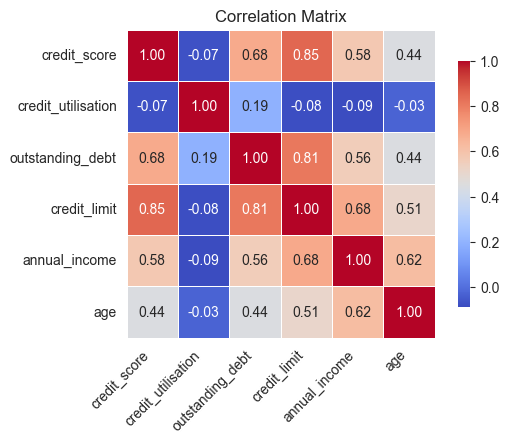

In [116]:
# Create a heatmap of the correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,square=True,cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.savefig("data_visualization/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

You can see a high correlation between credit limit and credit score (~0.85). Credit limit and annual income also show a high correlation. This correlation table can be used for further analysis, as it indicates whether one variable has a relationship with another variable.

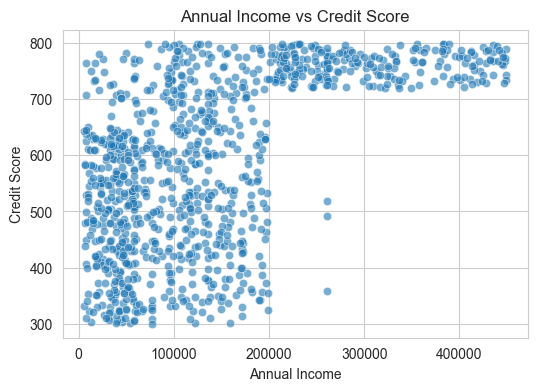

In [117]:
# Just looking if there is any relation between annual_income and credit score
plt.figure(figsize=(6,4))

sns.scatterplot(data=df_merged,x="annual_income",y="credit_score",alpha=0.6)
plt.title("Annual Income vs Credit Score")
plt.xlabel("Annual Income")
plt.ylabel("Credit Score")

plt.savefig("data_visualization/annual_income_vs_credit_score.png", dpi=300, bbox_inches="tight")
plt.show()

No clear pattern is observed.

<h2 style="text-align: center; color: darkorange;">Transactions Table</h2>

In [118]:
df_ts.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [119]:
df_ts.shape

(500000, 7)

#### **1. Data Cleaning**

**1.1 Handle NULL values: platform column**

In [120]:
df_ts.isnull().sum()

tran_id                0
cust_id                0
tran_date              0
tran_amount            0
platform            4941
product_category       0
payment_type           0
dtype: int64

The `platform` column has many null values. Let's examine them further.

In [121]:
df_ts[df_ts.platform.isnull()]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
355,356,58,2023-01-01,237,NaN,Electronics,Net Banking
418,419,383,2023-01-01,338,NaN,Electronics,Credit Card
607,608,421,2023-01-01,700,NaN,Electronics,Phonepe
844,845,945,2023-01-01,493,NaN,Sports,Credit Card
912,913,384,2023-01-01,85,NaN,Fashion & Apparel,Phonepe
...,...,...,...,...,...,...,...
499579,499580,924,2023-09-05,31,NaN,Fashion & Apparel,Gpay
499646,499647,944,2023-09-05,58445,NaN,Fashion & Apparel,Phonepe
499725,499726,620,2023-09-05,15,NaN,Sports,Net Banking
499833,499834,616,2023-09-05,97,NaN,Fashion & Apparel,Credit Card


In [122]:
df_ts.platform.unique()

<StringArray>
['Flipkart', 'Alibaba', 'Shopify', 'Amazon', 'Ebay', 'Meesho', 'Cred', nan]
Length: 8, dtype: str

In [123]:
df_ts.platform.mode()

0    Amazon
Name: platform, dtype: str

In [124]:
df_ts.platform.value_counts()

platform
Amazon      151443
Flipkart    122660
Alibaba      73584
Meesho       73271
Shopify      39416
Cred         24741
Ebay          9944
Name: count, dtype: int64

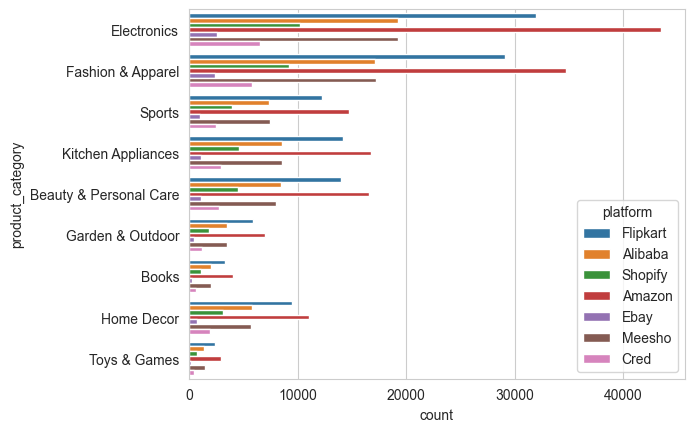

In [125]:
sns.countplot(y='product_category', hue='platform', data=df_ts)
plt.savefig("data_visualization/platform_usage_across_product_categories.png", dpi=300, bbox_inches="tight")

In the above chart, you can see that Amazon is the most used platform across all product categories. To handle the null values in `platform`, we can replace them with "Amazon", since it is the most frequently used platform.

In [126]:
df_ts.platform.mode()[0]

'Amazon'

In [127]:
df_ts['platform'] = df_ts['platform'].fillna(df_ts['platform'].mode()[0])

In [128]:
df_ts.isnull().sum()

tran_id             0
cust_id             0
tran_date           0
tran_amount         0
platform            0
product_category    0
payment_type        0
dtype: int64

Once again, we got rid of null values.

**1.2 Treat outliers: tran_amount**

In [129]:
df_ts.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.00000
mean,250000.500000,501.400428,3225.20733
std,144337.711635,288.641924,13098.74276
min,1.000000,1.000000,0.00000
25%,125000.750000,252.000000,64.00000
50%,250000.500000,502.000000,141.00000
75%,375000.250000,752.000000,397.00000
max,500000.000000,1000.000000,69999.00000


We can see transactions with a 0 amount. These appear to be invalid.

In [130]:
df_ts_zero = df_ts[df_ts.tran_amount==0]

In [131]:
df_ts_zero.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
517,518,147,2023-01-01,0,Amazon,Electronics,Credit Card
533,534,891,2023-01-01,0,Amazon,Electronics,Credit Card
586,587,108,2023-01-01,0,Amazon,Electronics,Credit Card


In [132]:
df_ts_zero.shape

(4734, 7)

In [133]:
df_ts_zero.platform.value_counts()

platform
Amazon    4734
Name: count, dtype: int64

In [134]:
df_ts_zero.payment_type.value_counts()

payment_type
Credit Card    4734
Name: count, dtype: int64

In [135]:
df_ts_zero[['platform','product_category','payment_type']].value_counts()

platform  product_category  payment_type
Amazon    Electronics       Credit Card     4734
Name: count, dtype: int64

It appears that when `platform = Amazon`, `product_category = Electronics`, and `payment_type = Credit Card`, we get these zero-value transactions. We need to look at other transactions in this group and compute the median to replace the zero values. The mean is not used because there are also some outliers in this column.

In [136]:
df_ts_1 = df_ts[(df_ts.platform=='Amazon')&(df_ts.product_category=="Electronics")&(df_ts.payment_type=="Credit Card")]

In [137]:
df_ts_1.head(5)

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
109,110,887,2023-01-01,635,Amazon,Electronics,Credit Card
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
173,174,676,2023-01-01,60439,Amazon,Electronics,Credit Card
190,191,763,2023-01-01,697,Amazon,Electronics,Credit Card


In [138]:
df_ts_1.shape

(15637, 7)

In [139]:
df_ts_1[df_ts_1.tran_amount>0]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
109,110,887,2023-01-01,635,Amazon,Electronics,Credit Card
173,174,676,2023-01-01,60439,Amazon,Electronics,Credit Card
190,191,763,2023-01-01,697,Amazon,Electronics,Credit Card
263,264,528,2023-01-01,421,Amazon,Electronics,Credit Card
311,312,936,2023-01-01,537,Amazon,Electronics,Credit Card
...,...,...,...,...,...,...,...
499766,499767,723,2023-09-05,909,Amazon,Electronics,Credit Card
499793,499794,586,2023-09-05,304,Amazon,Electronics,Credit Card
499812,499813,688,2023-09-05,425,Amazon,Electronics,Credit Card
499860,499861,373,2023-09-05,480,Amazon,Electronics,Credit Card


In [140]:
median_to_replace = df_ts_1[df_ts_1.tran_amount > 0].tran_amount.median()

In [141]:
median_to_replace

np.float64(554.0)

In [142]:
mask = ((df_ts['platform'] == 'Amazon') & (df_ts['product_category'] == 'Electronics') & (df_ts['payment_type'] == 'Credit Card') &
    (df_ts['tran_amount'] == 0))
df_ts.loc[mask, 'tran_amount'] = median_to_replace

In [143]:
df_ts.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,3230.452602
std,144337.711635,288.641924,13097.561071
min,1.000000,1.000000,2.000000
25%,125000.750000,252.000000,66.000000
50%,250000.500000,502.000000,146.000000
75%,375000.250000,752.000000,413.000000
max,500000.000000,1000.000000,69999.000000


In [144]:
df_ts[df_ts.tran_amount==0]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type


As you can see above, no zero values are left in the `tran_amount` column.

In [145]:
df_ts.tran_amount.describe()

count    500000.000000
mean       3230.452602
std       13097.561071
min           2.000000
25%          66.000000
50%         146.000000
75%         413.000000
max       69999.000000
Name: tran_amount, dtype: float64

<Axes: xlabel='tran_amount', ylabel='Count'>

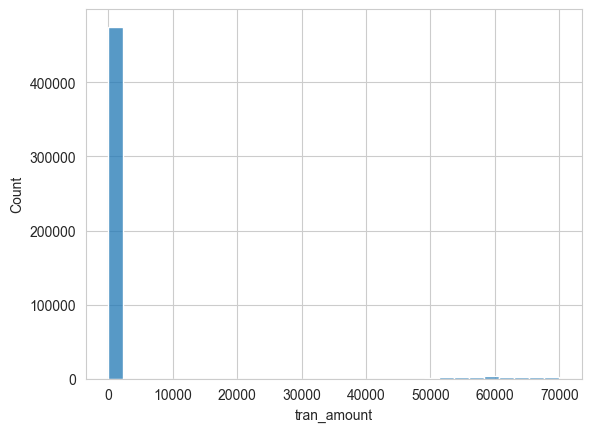

In [146]:
sns.histplot(df_ts.tran_amount, bins=30)

In [147]:
df_ts[df_ts['tran_amount']<10000].describe()

,tran_id,cust_id,tran_amount
count,475000.000000,475000.000000,475000.000000
mean,250041.699922,501.375499,240.667608
std,144285.259913,288.606185,244.487110
min,1.000000,1.000000,2.000000
25%,125126.750000,252.000000,63.000000
50%,250100.500000,502.000000,131.000000
75%,374928.250000,751.000000,348.000000
max,500000.000000,1000.000000,999.000000


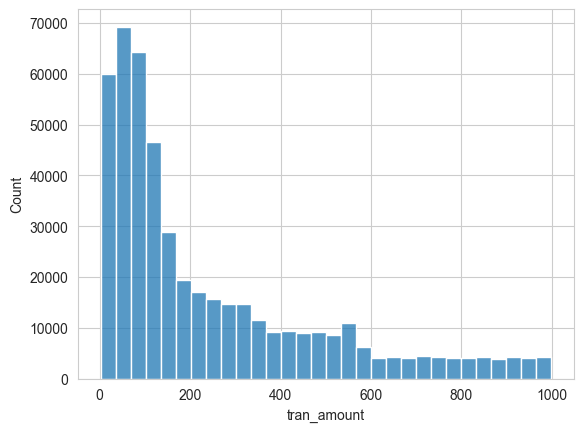

In [148]:
sns.histplot(df_ts[df_ts.tran_amount<10000].tran_amount, bins=30)
plt.savefig("data_visualization/transaction_amount.png", dpi=300, bbox_inches="tight")

In [149]:
Q1, Q3 = df_ts['tran_amount'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower = Q1 - 2 * IQR
upper = Q3 + 2 * IQR

lower, upper

(-628.0, 1107.0)

In [150]:
df_ts[df_ts.tran_amount<upper].tran_amount.max()

np.int64(999)

In [151]:
df_ts[df_ts.tran_amount>upper].tran_amount.min()

np.int64(50000)

In [152]:
df_ts_outliers = df_ts[df_ts.tran_amount>=upper]
df_ts_outliers.shape

(25000, 7)

In [153]:
df_ts_outliers

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,55131,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,59679,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,60184,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,54678,Meesho,Sports,Gpay


In [154]:
df_ts_normal = df_ts[df_ts.tran_amount<upper]

In [155]:
df_ts_normal

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking
...,...,...,...,...,...,...,...
499994,499995,679,2023-09-05,59,Ebay,Beauty & Personal Care,Gpay
499995,499996,791,2023-09-05,43,Amazon,Books,Phonepe
499997,499998,57,2023-09-05,224,Amazon,Garden & Outdoor,Phonepe
499998,499999,629,2023-09-05,538,Flipkart,Home Decor,Gpay


In [156]:
tran_mean_per_category = df_ts_normal.groupby("product_category")["tran_amount"].mean()

In [157]:
tran_mean_per_category

product_category
Beauty & Personal Care     92.167205
Books                      29.553515
Electronics               510.172685
Fashion & Apparel          64.553463
Garden & Outdoor          125.630277
Home Decor                302.487561
Kitchen Appliances        176.773288
Sports                    269.181631
Toys & Games               50.333298
Name: tran_amount, dtype: float64

In [158]:
df_ts.loc[df_ts_outliers.index]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,55131,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,59679,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,60184,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,54678,Meesho,Sports,Gpay


In [159]:
df_ts['tran_amount'] = df_ts['tran_amount'].astype(float)

In [160]:
df_ts.loc[df_ts_outliers.index, 'tran_amount'] = df_ts_outliers['product_category'].map(tran_mean_per_category)

In [161]:
df_ts.loc[df_ts_outliers.index]

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,92.167205,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,50.333298,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,176.773288,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,64.553463,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,176.773288,Shopify,Kitchen Appliances,Credit Card
...,...,...,...,...,...,...,...
499742,499743,868,2023-09-05,64.553463,Meesho,Fashion & Apparel,Gpay
499888,499889,614,2023-09-05,64.553463,Meesho,Fashion & Apparel,Net Banking
499900,499901,811,2023-09-05,269.181631,Flipkart,Sports,Debit Card
499966,499967,662,2023-09-05,269.181631,Meesho,Sports,Gpay


You can now see that we got rid of outliers from the `tran_amount` column.

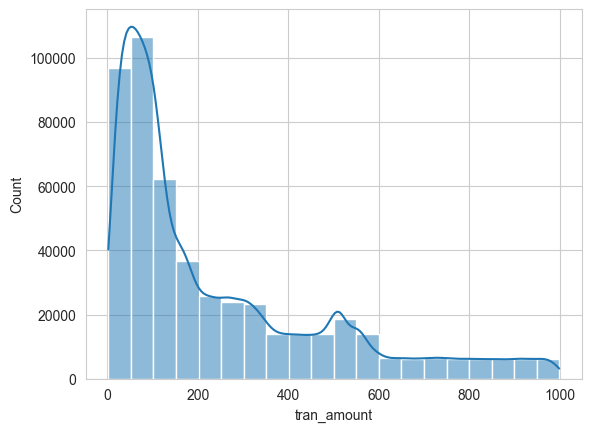

In [162]:
sns.histplot(x='tran_amount', data=df_ts, bins=20, kde=True)
plt.savefig("data_visualization/transaction_amount_cleaned.png", dpi=300, bbox_inches="tight")

The above histogram shows transactions after the removal of outliers. The distribution is right-skewed, and transaction amounts are now below 1000.

#### **2. Data Visualization**

**2.1 Payment type distribution**

In [163]:
df_ts.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63.0,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99.0,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471.0,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33.0,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68.0,Amazon,Fashion & Apparel,Net Banking


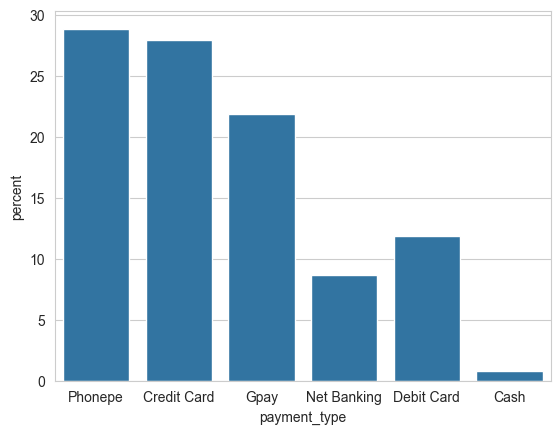

In [164]:
sns.countplot(x=df_ts.payment_type, stat='percent')
plt.savefig("data_visualization/payment_types.png", dpi=300, bbox_inches="tight")


**2.2 Distribution of payment across age groups**

In [165]:
df_merged_2 = df_merged.merge(df_ts, on='cust_id', how='inner')
df_merged_2.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,...,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode,tran_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-749,40000.0,1283,2023-01-01,30.0,Shopify,Fashion & Apparel,Net Banking
1,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-749,40000.0,1382,2023-01-01,96.0,Amazon,Sports,Debit Card
2,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-749,40000.0,1521,2023-01-01,86.0,Meesho,Garden & Outdoor,Gpay
3,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-749,40000.0,1576,2023-01-01,149.0,Amazon,Beauty & Personal Care,Phonepe
4,1,Manya Acharya,Female,51.0,City,Business Owner,358211.0,Married,49-65,749,...,0.0,40000.0,700-749,40000.0,1757,2023-01-01,37.0,Flipkart,Fashion & Apparel,Credit Card


In [166]:
df_merged_2.shape

(500000, 22)

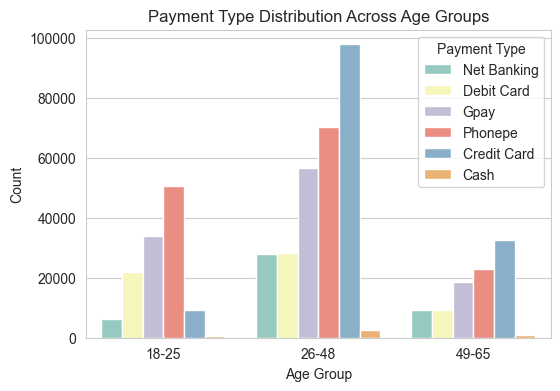

In [167]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_merged_2,x="age_group",hue="payment_type",palette="Set3")
plt.title("Payment Type Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Payment Type")

plt.savefig("data_visualization/payment_type_distribution_across_age_groups.png", dpi=300, bbox_inches="tight")
plt.show()

From the above analysis, we can see that the 18–25 age group has less exposure to credit cards compared to other groups.

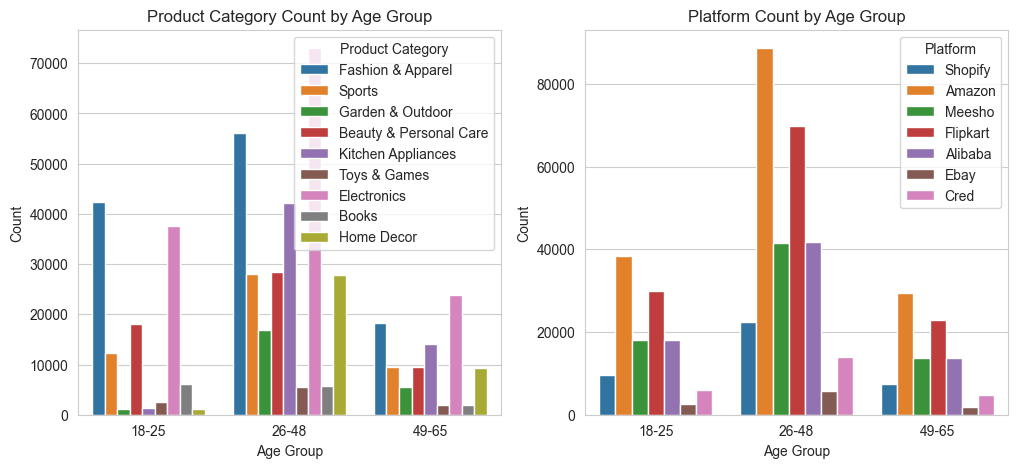

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df_merged_2,x="age_group",hue="product_category",ax=axes[0])
axes[0].set_title("Product Category Count by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Count")
axes[0].legend(title="Product Category")

sns.countplot(data=df_merged_2,x="age_group",hue="platform",ax=axes[1])
axes[1].set_title("Platform Count by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Count")
axes[1].legend(title="Platform")

plt.savefig("data_visualization/product_category_and_platform_count_across_age_groups.png", dpi=300, bbox_inches="tight")
plt.show()

**Observations:**
1. The top three purchasing categories for customers in the 18–25 age group are Electronics, Fashion & Apparel, and Beauty & Personal Care.
2. The most used platforms are Amazon, Flipkart, and Alibaba.

**2.3 Average transaction amount**

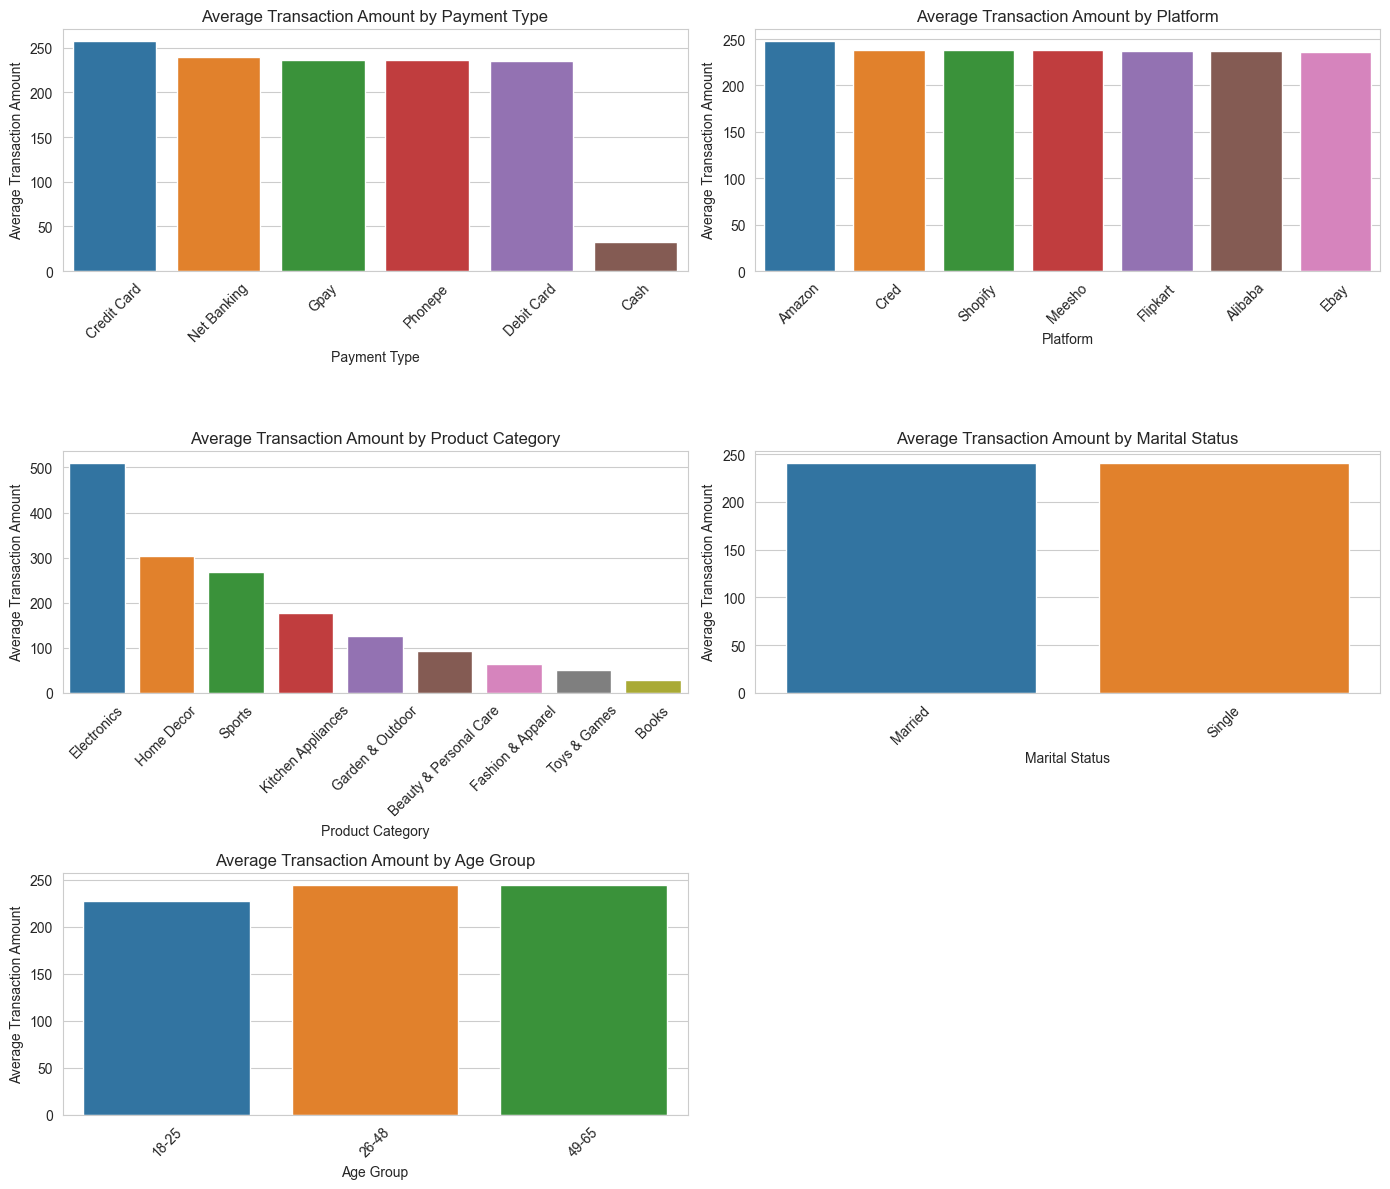

In [169]:
# Average Transaction Amount by Categorical Features

cat_cols = ['payment_type','platform','product_category','marital_status','age_group']

num_rows = 3
# Create subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(14, 4 * num_rows))

# Flatten the axes array to make it easier to iterate
axes = axes.flatten()

# Create subplots for each categorical column
for i, col in enumerate(cat_cols):

    # Calculate the average annual income for each category
    avg_data = (df_merged_2.groupby(col)['tran_amount'].mean().sort_values(ascending=False).reset_index())

    sns.barplot(data=avg_data,x=col,y="tran_amount",ax=axes[i],palette="tab10")
    axes[i].set_title(f"Average Transaction Amount by {col.replace('_',' ').title()}")
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel("Average Transaction Amount")

    # Rotate x-axis labels for better readability
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig("data_visualization/average_transaction_amount_by_customer_segments.png", dpi=300, bbox_inches="tight")
plt.show()

In [170]:
df_ts.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,240.672998
std,144337.711635,288.641924,241.696597
min,1.000000,1.000000,2.000000
25%,125000.750000,252.000000,64.553463
50%,250000.500000,502.000000,133.000000
75%,375000.250000,752.000000,349.000000
max,500000.000000,1000.000000,999.000000


#### **3. Further analysis on age group**

Let us perform further analysis on the age groups to examine their average income, credit limit, and credit score.

In [171]:
# Group the data by age group and calculate the average credit_limit and credit_score
age_group_metrics = df_merged.groupby('age_group')[['annual_income', 'credit_limit', 'credit_score']].mean().reset_index()
age_group_metrics

,age_group,annual_income,credit_limit,credit_score
0,18-25,37091.235772,1130.081301,484.451220
1,26-48,145869.623457,20560.846561,597.569665
2,49-65,260165.925134,41699.197861,701.524064


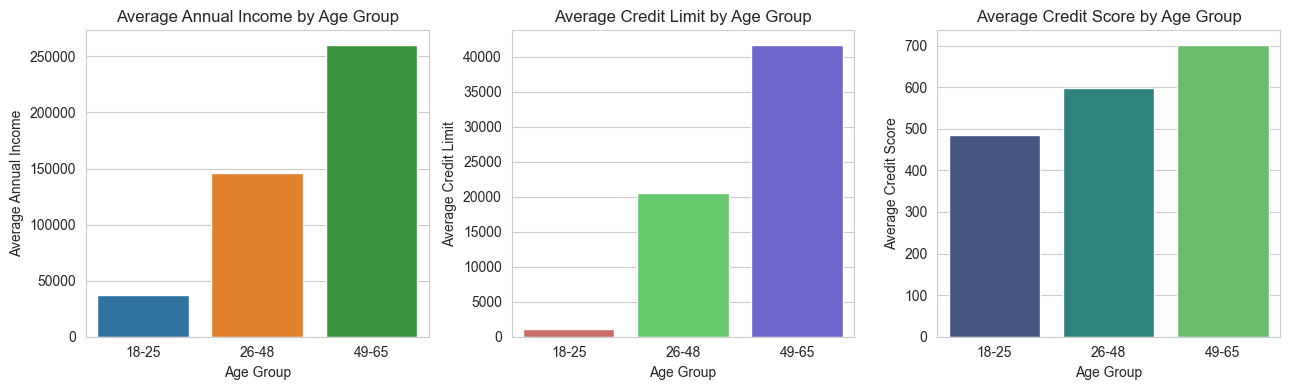

In [172]:
# Average Income, Credit Limit, and Credit Score by Age Group

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Average annual income by age group
sns.barplot(data=age_group_metrics,x='age_group',y='annual_income',palette='tab10',ax=axes[0])
axes[0].set_title('Average Annual Income by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Average Annual Income')

# Average credit limit by age group
sns.barplot(data=age_group_metrics,x='age_group',y='credit_limit',palette='hls',ax=axes[1])
axes[1].set_title('Average Credit Limit by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Credit Limit')

# Average credit score by age group
sns.barplot(data=age_group_metrics,x='age_group',y='credit_score',palette='viridis',ax=axes[2])
axes[2].set_title('Average Credit Score by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Average Credit Score')

plt.tight_layout()

plt.savefig("data_visualization/average_financial_metrics_by_age_group.png", dpi=300, bbox_inches="tight")
plt.show()

<h2 style="text-align: center; color: darkorange;">Finalize Target Market For a Trial Credit Card Launch</h2>

#### **Targeting Untapped market**

1. People in the 18–25 age group account for approximately 25% of the customer base in the dataset.
2. The average annual income for this group is below 50k.
3. They do not have much credit history, which is reflected in their credit score and credit limit.
4. The usage of credit cards as a payment type is relatively low compared to other groups.
5. The average transaction value for credit card payments is also lower in this age group compared to others.
6. The top three shopping product categories are Electronics, Fashion & Apparel, and Beauty & Personal Care.


<div style="text-align:center;">

  <!-- Top Row -->
  <img src="data_visualization/distribution_of_age_groups.png"
       style="width:40%; height:420px; object-fit:contain; vertical-align:middle;">
  <img src="data_visualization/product_category_and_platform_count_across_age_groups.png"
       style="width:55%; height:420px; object-fit:contain; vertical-align:middle;">

  <!-- Controlled spacing -->
  <div style="margin: 10px 0;"></div>

  <!-- Bottom Row -->
  <img src="data_visualization/average_financial_metrics_by_age_group.png"
       style="width:65%; height:420px; object-fit:contain; vertical-align:middle;">
  <img src="data_visualization/payment_type_distribution_across_age_groups.png"
       style="width:30%; height:420px; object-fit:contain; vertical-align:middle;">

</div>